In [ ]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import prettypyplot as pplt
import msmhelper as mh
import importlib
# --
import utils
importlib.reload(utils)
from utils import mean_first_passage_time, stationary_distribution, infinitesimal_generator
# --
import _013_PRC_clustering
importlib.reload(_013_PRC_clustering)
from _013_PRC_clustering import PcaCluster
# --
import _007_EXP_model_validation
importlib.reload(_007_EXP_model_validation)
from _007_EXP_model_validation import get_md_empiricial_distribution
# --
import _015_PRC_clustered_chains
importlib.reload(_015_PRC_clustered_chains)
from _015_PRC_clustered_chains import generate_transition_matrix

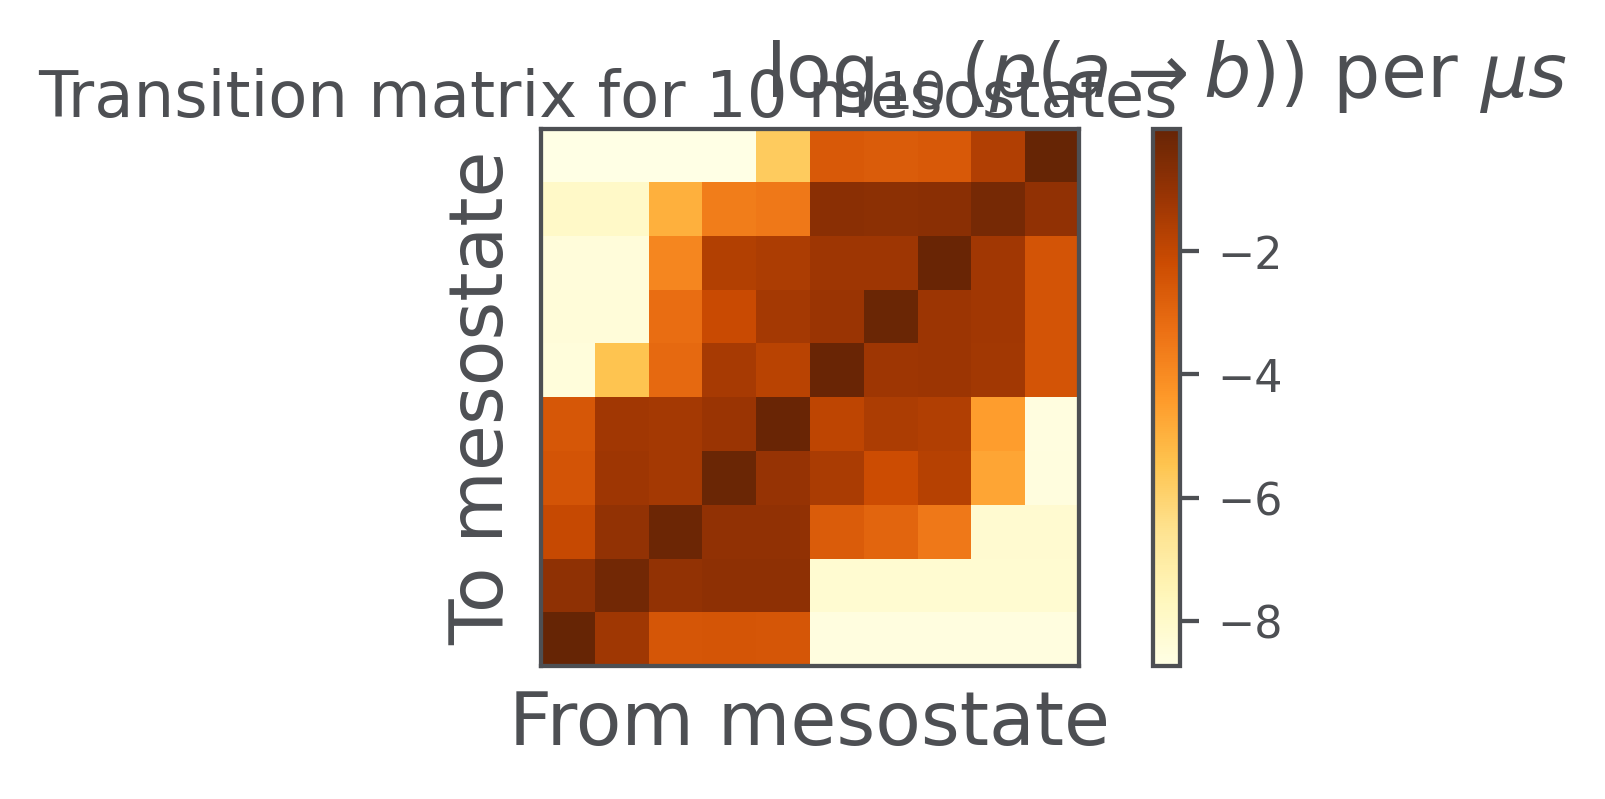

/tmp/ipykernel_3325864/97700729.py:27: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(Q), cmap='YlOrBr')


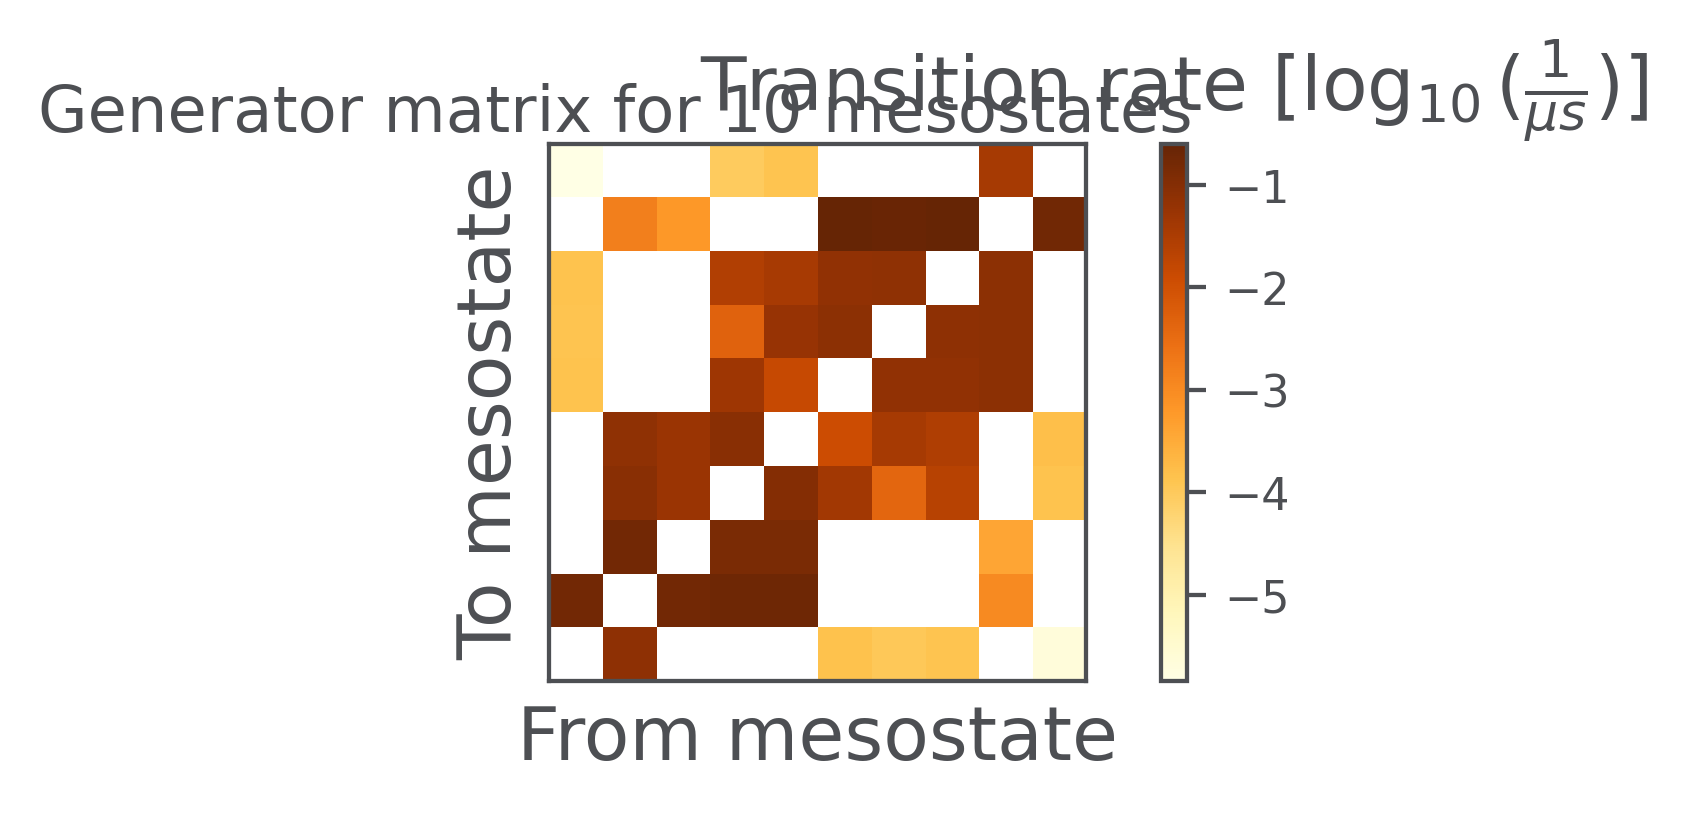

In [ ]:
for n_clusters in [10, 20, 40, 80, 160, 320, 640, 1280]:
    with open(f"data/clustered/interactions-150-180-100ns-3k-hist-74pca-kmeans-{n_clusters}clusters.pickle", "rb") as f:
        clustered_data = pickle.load(f)
    transition_matrix = generate_transition_matrix(clustered_data, n_clusters, init_1 = True)
    with open(f"/cs/usr/roi.eliasian/LabFolder/Master/NPC-markov/data/transition_matrices/cluster-kmeans/74pca-{n_clusters}clusters.pickle", "wb") as f:
        pickle.dump(transition_matrix, f)
    
    plt.suptitle(f"Transition matrix for {n_clusters} mesostates")
    # turn of x and y ticks
    plt.xticks([])
    plt.yticks([])
    plt.xlabel("From mesostate", fontsize=14)
    plt.ylabel("To mesostate", fontsize=14)
    plt.imshow(np.log10(transition_matrix), cmap='YlOrBr')
    cbar = plt.colorbar()
    cbar.ax.set_title(r'$\log_{10} (p(a \to b))$ per $\mu s$', fontsize=14)
    plt.show()
    
    
    Q = infinitesimal_generator(transition_matrix, dt=1) # rate at 1 / us
    plt.suptitle(f"Generator matrix for {n_clusters} mesostates")
    # turn of x and y ticks
    plt.xticks([])
    plt.yticks([])
    plt.xlabel("From mesostate", fontsize=14)
    plt.ylabel("To mesostate", fontsize=14)
    plt.imshow(np.log10(Q), cmap='YlOrBr')
    cbar = plt.colorbar()
    cbar.ax.set_title(r'Transition rate $[\log_{10} (\frac{1}{\mu s})]$', fontsize=14)
    plt.show()
    
# for n_clusters in [10, 20, 40, 80, 160, 320]:
#     with open(f"data/clustered/interactions-150-180-100ns-3k-hist-bisectingkmeans-{n_clusters}clusters.pickle", "rb") as f:
#         clustered_data = pickle.load(f)
#     transition_matrix = generate_transition_matrix(clustered_data, n_clusters, init_1 = True)
#     with open(f"/cs/usr/roi.eliasian/LabFolder/Master/NPC-markov/data/transition_matrices/cluster-bisectingkmeans/{n_clusters}clusters.pickle", "wb") as f:
#         pickle.dump(transition_matrix, f)
#     plt.imshow(np.log(transition_matrix), cmap='hot')
#     plt.colorbar()
#     plt.show()

permiability for 10 clusters: 20270.43873444648 n / s / uM / NPC 
permiability for 20 clusters: 13629.252695435422 n / s / uM / NPC 
permiability for 40 clusters: 15764.244015889073 n / s / uM / NPC 
permiability for 80 clusters: 11896.265051787599 n / s / uM / NPC 
permiability for 160 clusters: 11799.433204249104 n / s / uM / NPC 
permiability for 320 clusters: 7777.2870416503865 n / s / uM / NPC 
permiability for 640 clusters: 7663.687362968814 n / s / uM / NPC 
permiability for 1280 clusters: 9417.591401698095 n / s / uM / NPC 


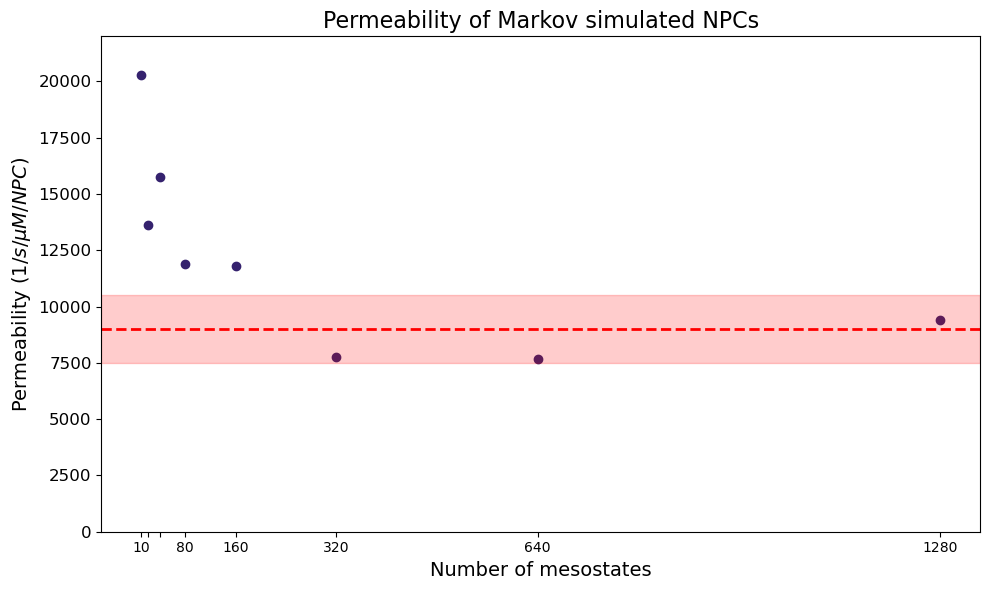

In [9]:
def mm_permiability(tm, states, bottom_states=None, top_states=None):
    
    # Simulate
    mfpt = mean_first_passage_time(tm, states, bottom_states, top_states) # units: 1000ns
    mfpt_s = 1e-6 * mfpt # units: s
    transport_events_per_s = 1 / mfpt_s # units: 1/s
    concentration_uM = 50/250 # approx, single molecule
    
    # units : n_events / s / uM / NPC 
    perm = transport_events_per_s / concentration_uM
    
    return perm

variant = "kmeans"

permiabilities = []
for n_clusters in [10, 20, 40, 80, 160, 320, 640, 1280]:
    with open(f"/cs/usr/roi.eliasian/LabFolder/Master/NPC-markov/data/transition_matrices/cluster-{variant}/74pca-{n_clusters}clusters.pickle", "rb") as f:
        tm = pickle.load(f)
    with open(f"data/clusterings/interactions-150-180-100ns-3k-hist-74pca-{variant}-{n_clusters}clusters.pickle", "rb") as f:
        pca_cluster = pickle.load(f)
    centers = pca_cluster.get_inverse_centers()
    bottom_indices = np.where(centers[:, 0] > 0.9)[0]
    top_indices = np.where(centers[:, -1] > 0.9)[0]
    # print(bottom_indices, top_indices)
    
    
    premiability = mm_permiability(tm, [f"{i}" for i in range(n_clusters)], bottom_states=list(bottom_indices), top_states=list(top_indices))
    permiabilities.append(premiability)
    print(f"permiability for {n_clusters} clusters: {premiability} n / s / uM / NPC ")

plt.figure(figsize=(10, 6))
plt.scatter([10, 20, 40, 80, 160, 320, 640, 1280], permiabilities, marker='o', color="#35226e")
plt.xlabel("Number of mesostates", fontsize=14)
plt.ylabel(r"Permeability $(1/s/\mu M/NPC)$", fontsize=14)
# plt.xscale('log', base=2)
# plt.xticks([10, 20, 40, 80, 160, 320, 640, 1280],
#            [f"{10}", f"{20}", f"{40}", f"{80}", f"{160}", f"{320}", f"{640}", f"{1280}"])
plt.ylim(0, 22000)
plt.yticks(fontsize=12)
plt.title("Permeability of Markov simulated NPCs", fontsize=16)
plt.xticks([10, 20, 40, 80, 160, 320, 640, 1280], labels=[f"{10}", "", f"", f"{80}", f"{160}", f"{320}", f"{640}", f"{1280}"])


plt.axhline(y=9000, color='red', linestyle='--', linewidth=2, label='Experimental value')
plt.axhspan(9000-1500, 9000+1500, alpha=0.2, color='red', label='Error range (±1.5k)')

# plt.grid(True)
# plt.grid(True)
plt.tight_layout()
plt.show()

/cs/labs/ravehb/roi.eliasian/miniconda3/envs/general_notebooks/lib/python3.10/site-packages/msmhelper/msm/timescales.py:81: ComplexWarning: Casting complex values to real discards the imaginary part
  impl_timescales[idx] = _implied_timescales(


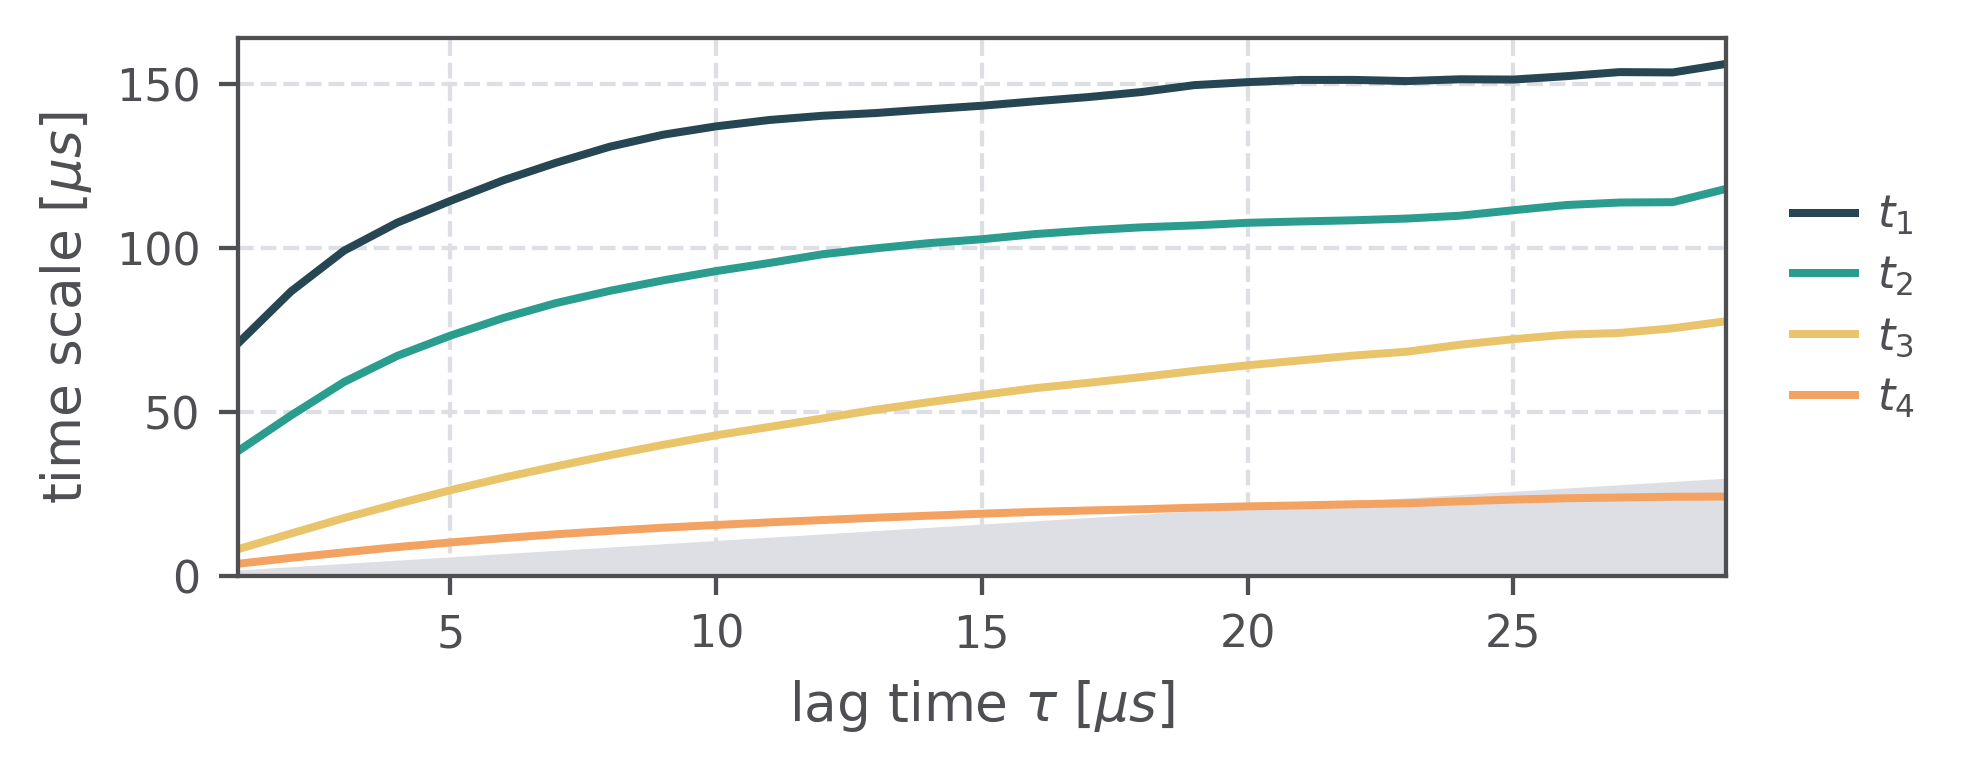

In [36]:
# Validate convergence with implied timescales
# https://moldyn.github.io/msmhelper/tutorials/msm/#implied-timescales
with open(f"data/clustered/interactions-150-180-100ns-3k-hist-74pca-kmeans-{320}clusters.pickle", "rb") as f:
        traj = pickle.load(f)


# pplt.use_style(figsize=(5, 2), colors='pastel_autumn', latex=False)

def plot_impl_times(impl_times):
    """Plot the implied timescales"""
    _, ax = plt.subplots()
    for idx, impl_time in enumerate(impl_times.T):
        ax.plot(lagtimes, impl_time, label=f'$t_{idx + 1}$')

    ax.set_xlim(lagtimes[0], lagtimes[-1])
    # highlight diagonal
    ax.fill_between(ax.get_xlim(), ax.get_xlim())
    ax.set_ylim(0, impl_times.max() * 1.05)
    ax.set_xlabel(r'lag time $\tau$ [frames]')
    ax.set_ylabel('time scale [frames]')
    plt.legend()


lagtimes = range(1, 30)
impl_times = mh.msm.implied_timescales(traj, lagtimes, ntimescales=4)

pplt.use_style(figsize=(5, 2), colors='pastel_autumn', latex=False)
def plot_impl_times(impl_times):
    """Plot the implied timescales"""
    _, ax = plt.subplots()
    for idx, impl_time in enumerate(impl_times.T):
        ax.plot(lagtimes, impl_time, label=f'$t_{idx + 1}$')

    ax.set_xlim(lagtimes[0], lagtimes[-1])
    # highlight diagonal
    ax.fill_between(ax.get_xlim(), ax.get_xlim(), color='pplt:grid')
    ax.set_ylim(0, impl_times.max() * 1.05)
    ax.set_xlabel(r'lag time $\tau$ $[\mu s]$')
    ax.set_ylabel(r'time scale $[\mu s]$')
    pplt.legend(outside='right', frameon=False)

plot_impl_times(impl_times)

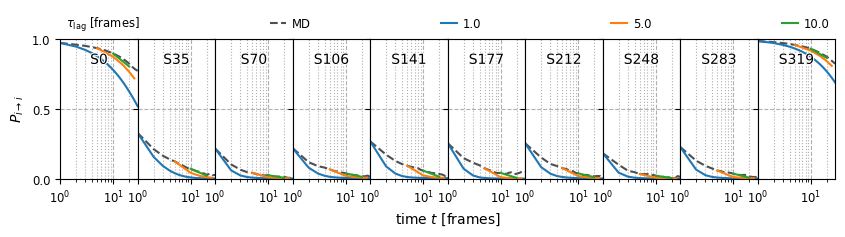

In [2]:
# Validate markov property with Chapman-Kolmogorov Test
# https://moldyn.github.io/msmhelper/tutorials/msm/#implied-timescales

n_clusters = 320

with open(f"data/clustered/interactions-150-180-100ns-3k-hist-74pca-kmeans-{n_clusters}clusters.pickle", "rb") as f:
        traj = pickle.load(f)

# change figsize
pplt.update_style(figsize=(10, 2))

lagtimes = [1, 5, 10]
tmax = 29

# estimating the CK test
ck = mh.msm.ck_test(traj, lagtimes, tmax)

# plot the results
states = [int(i) for i in np.linspace(0, 319, 10)]
# states = [0, n_clusters - 1]
_ = mh.plot.plot_ck_test(ck=ck, states=states, grid=(1, 10))

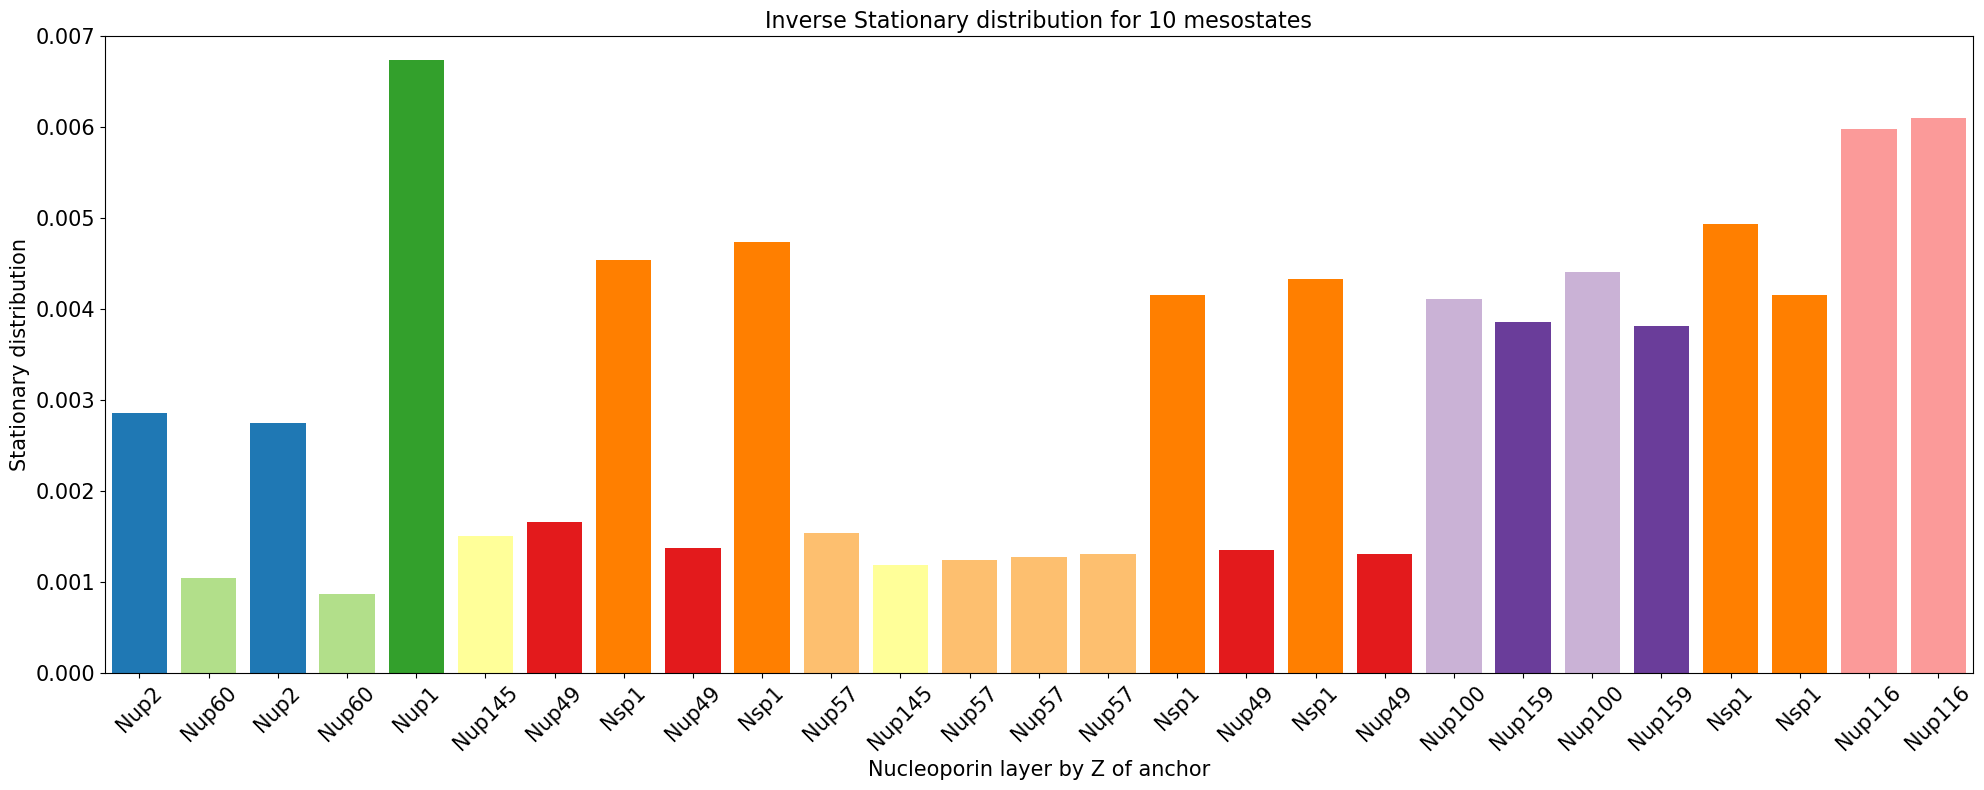

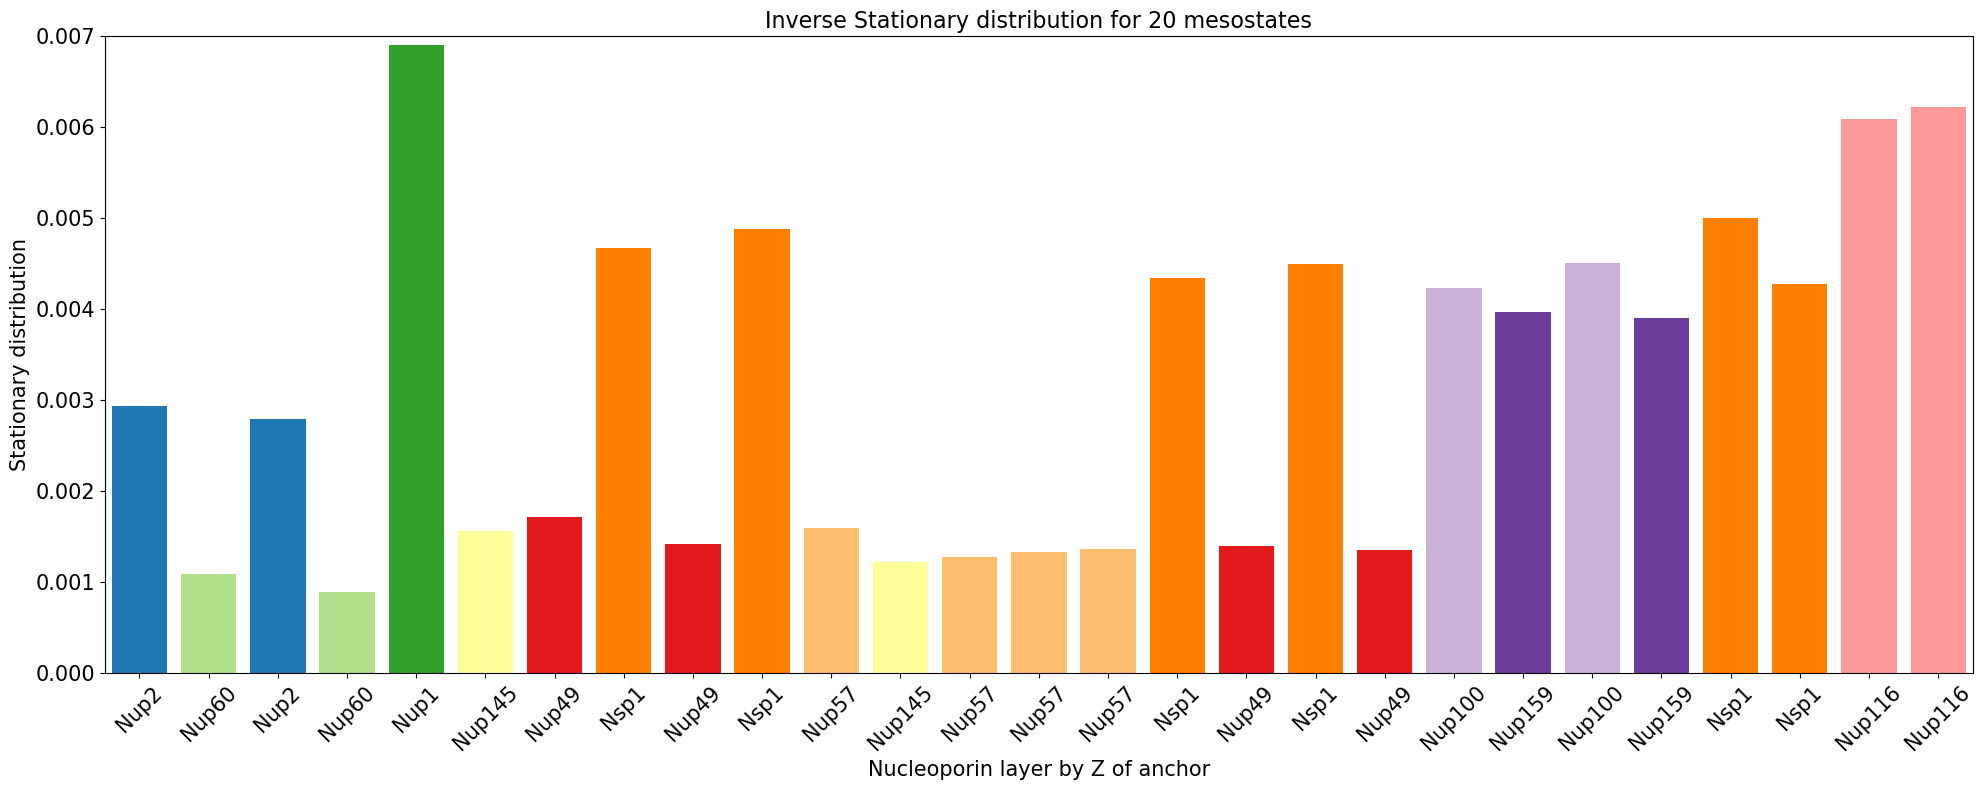

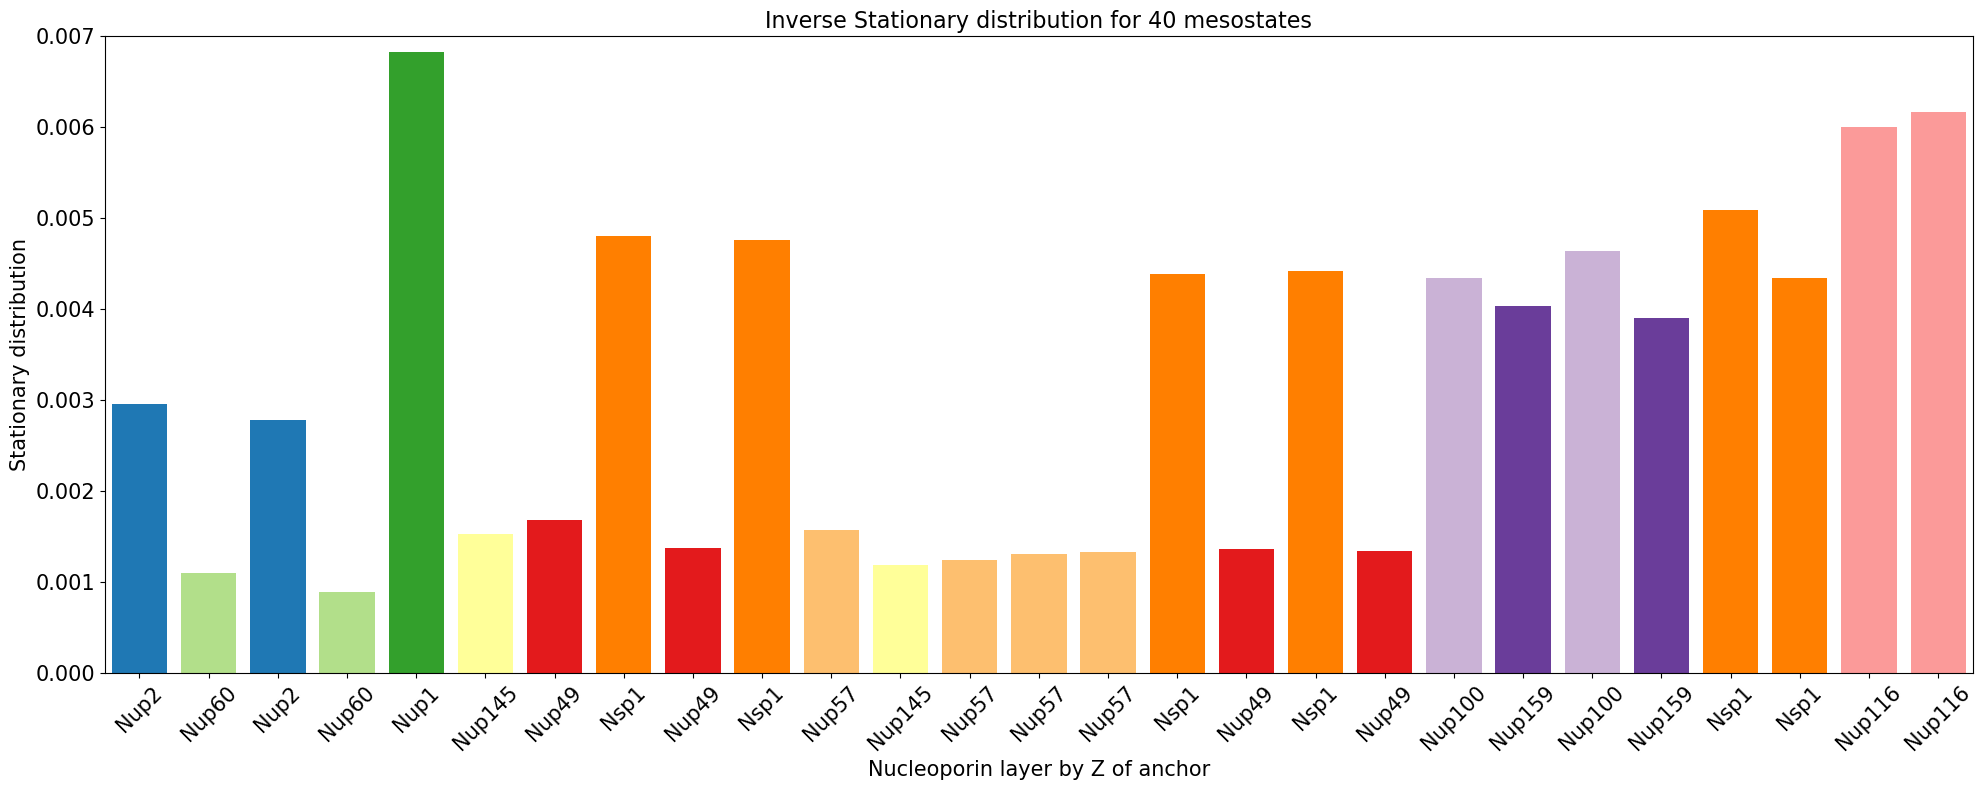

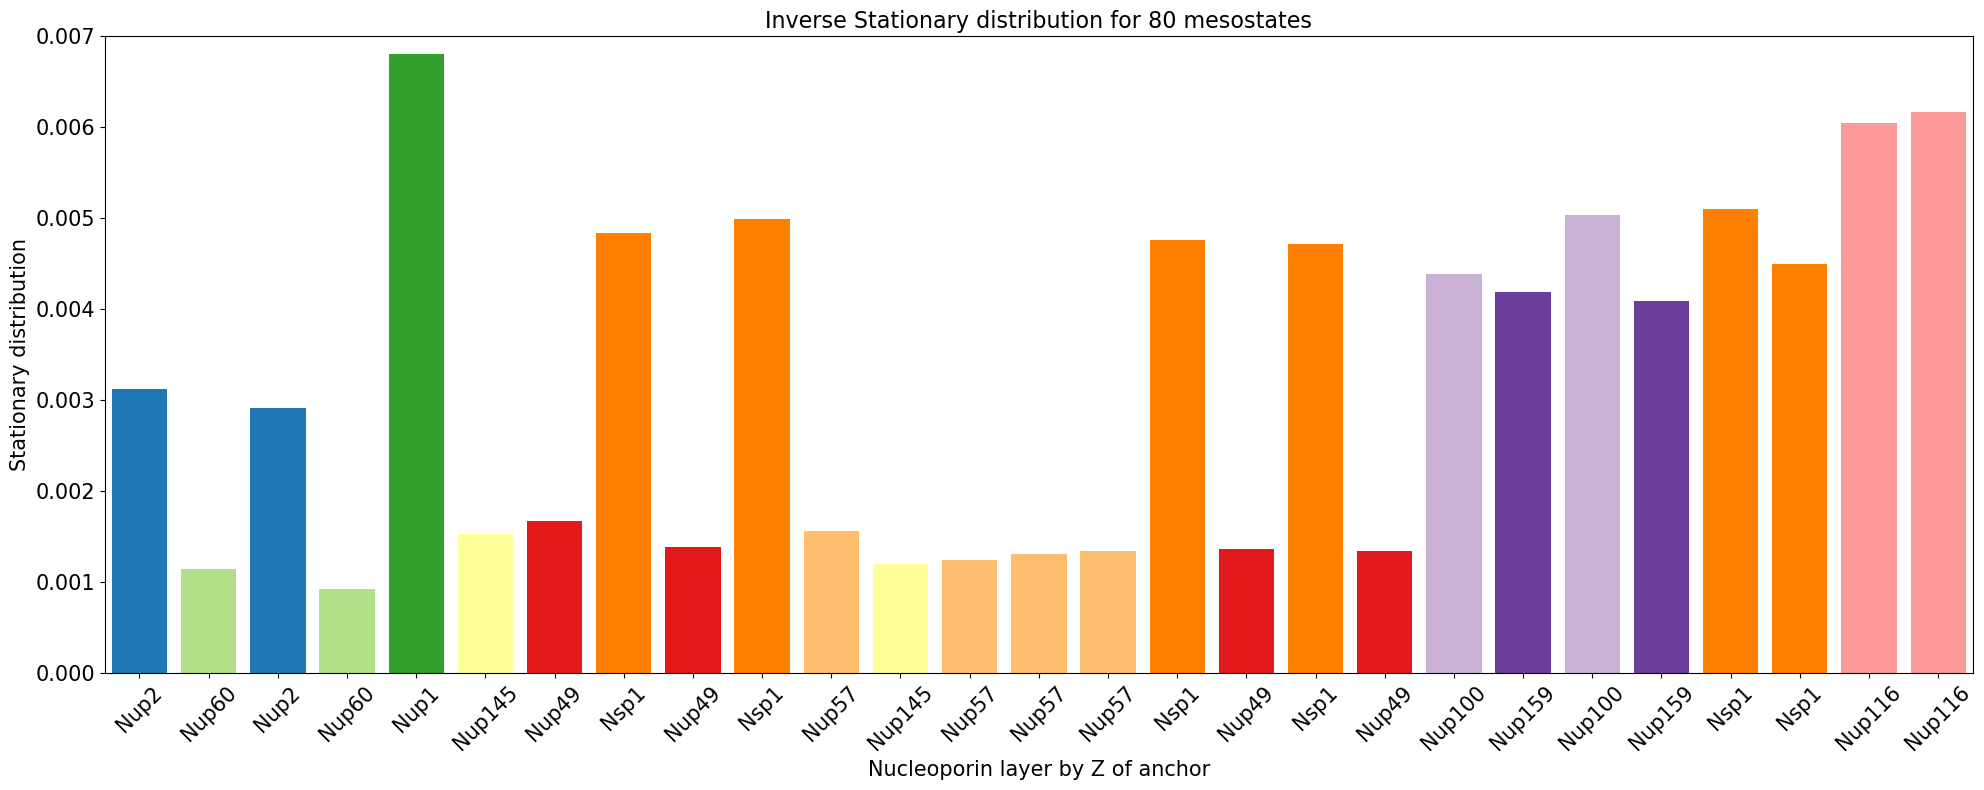

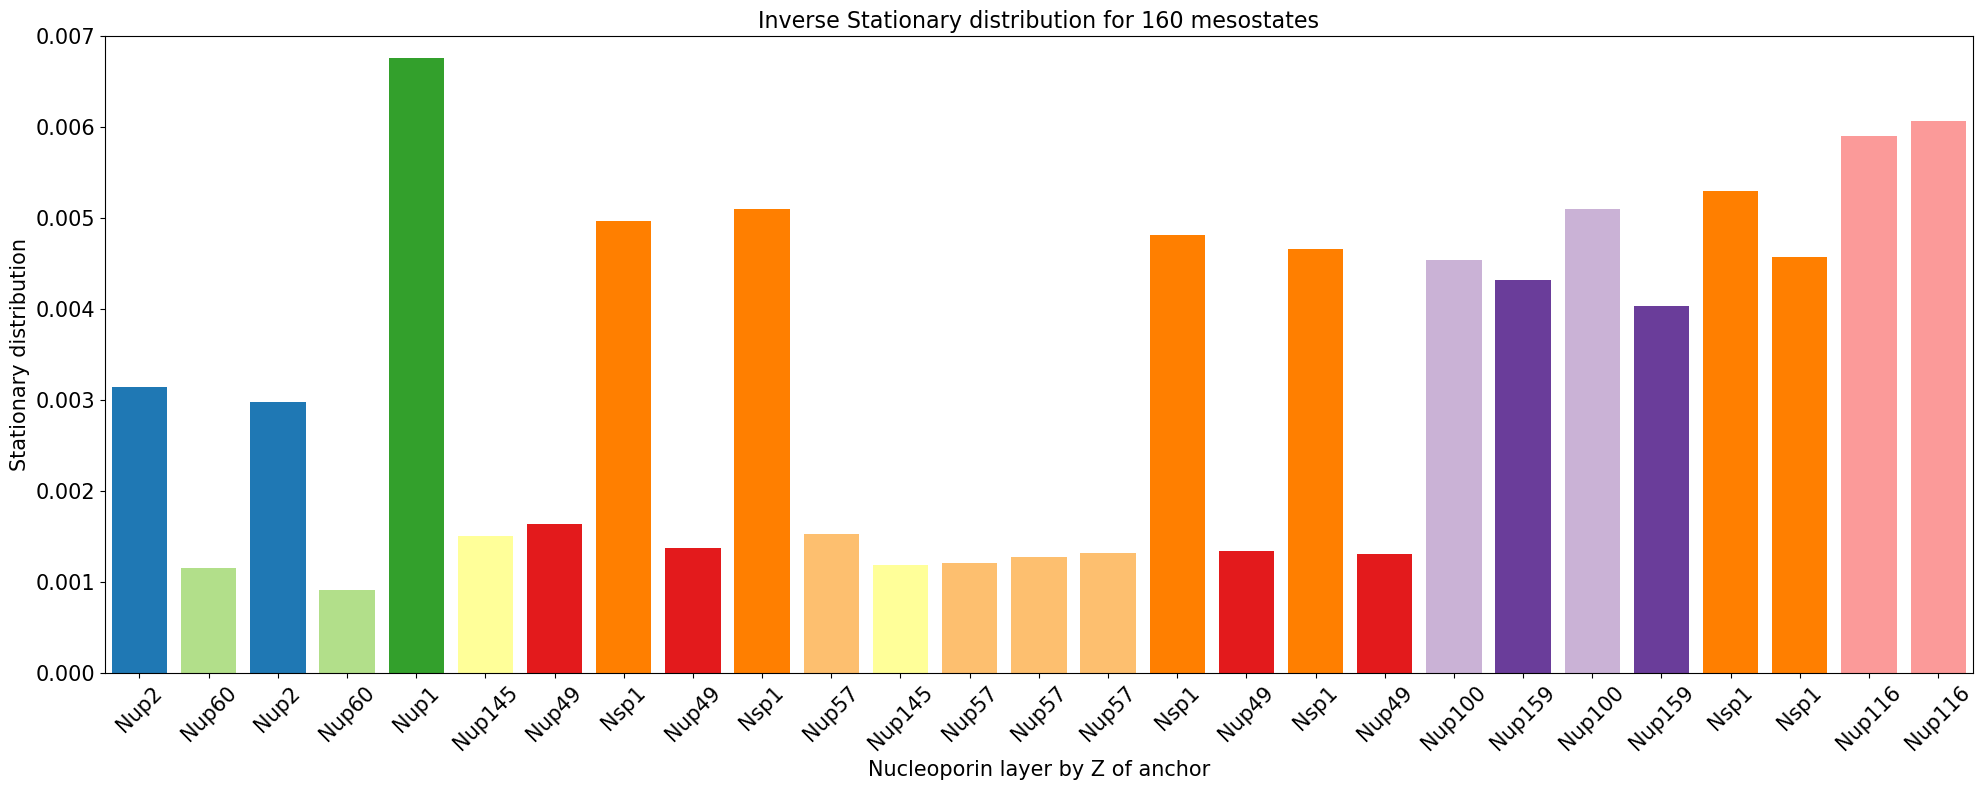

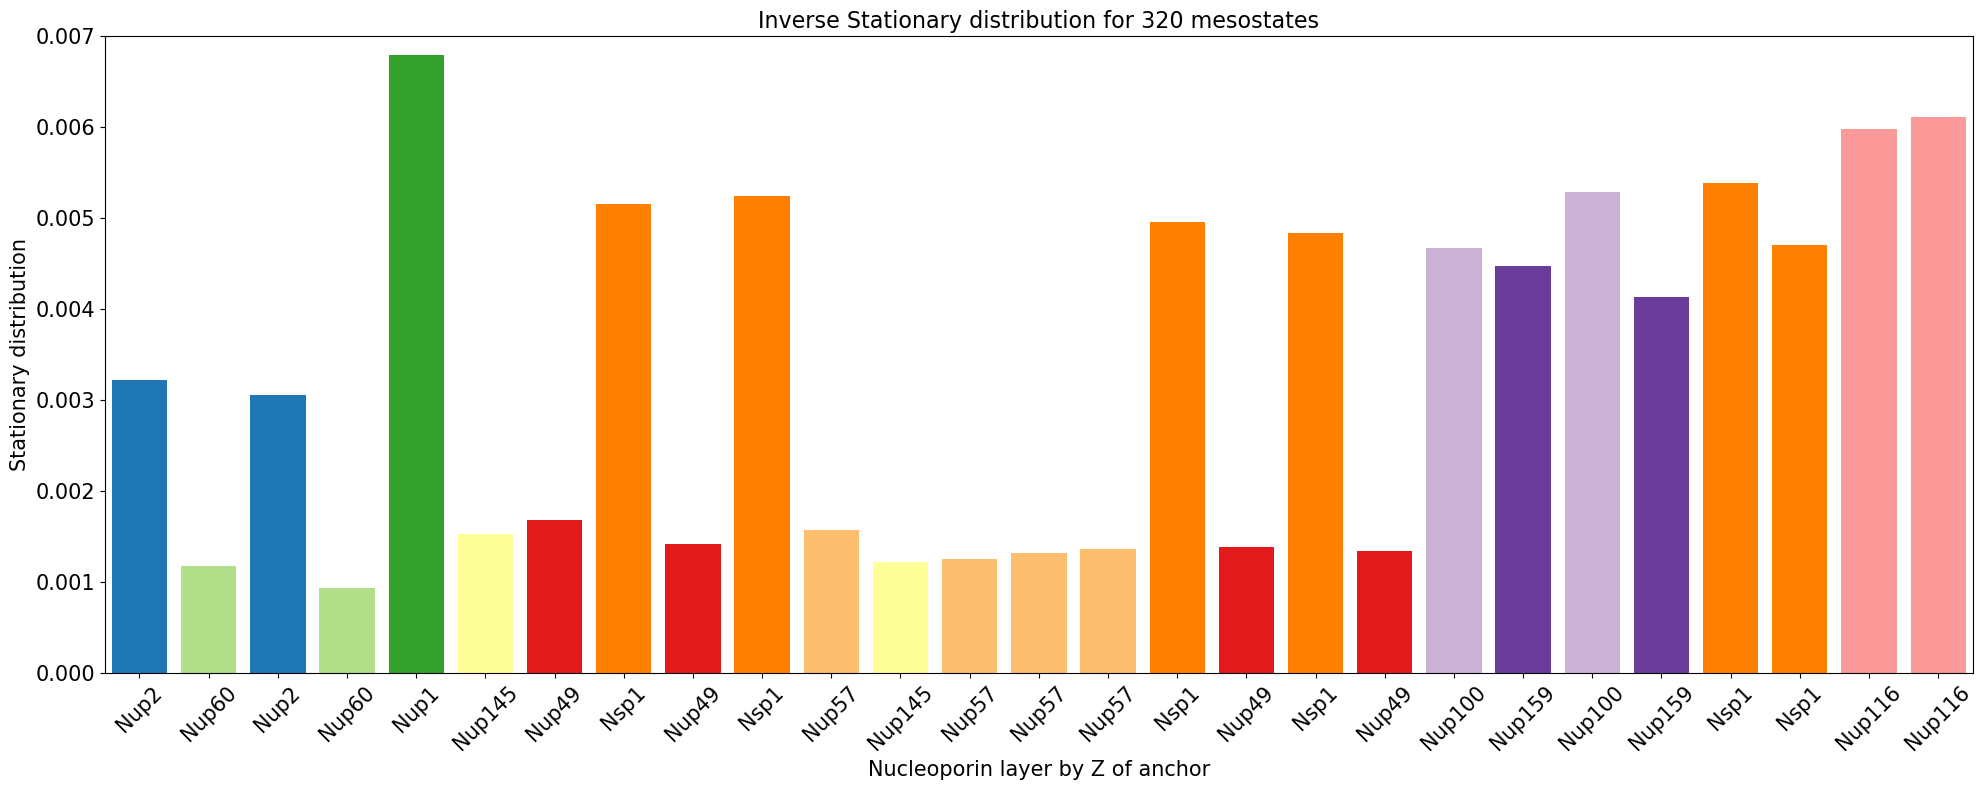

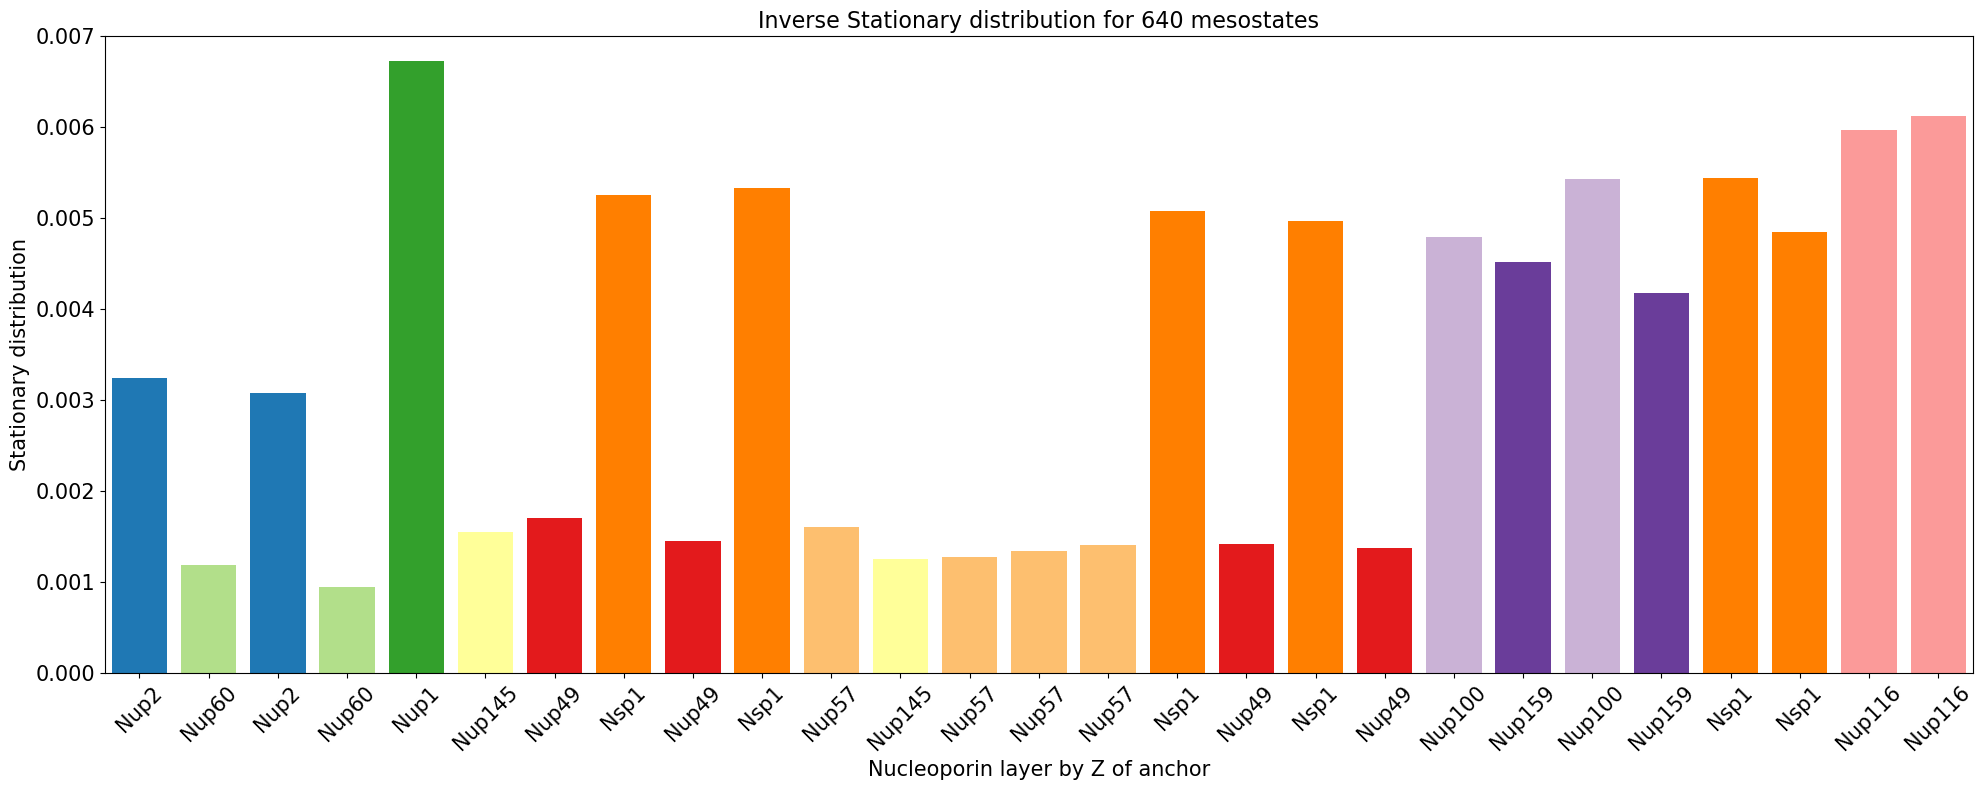

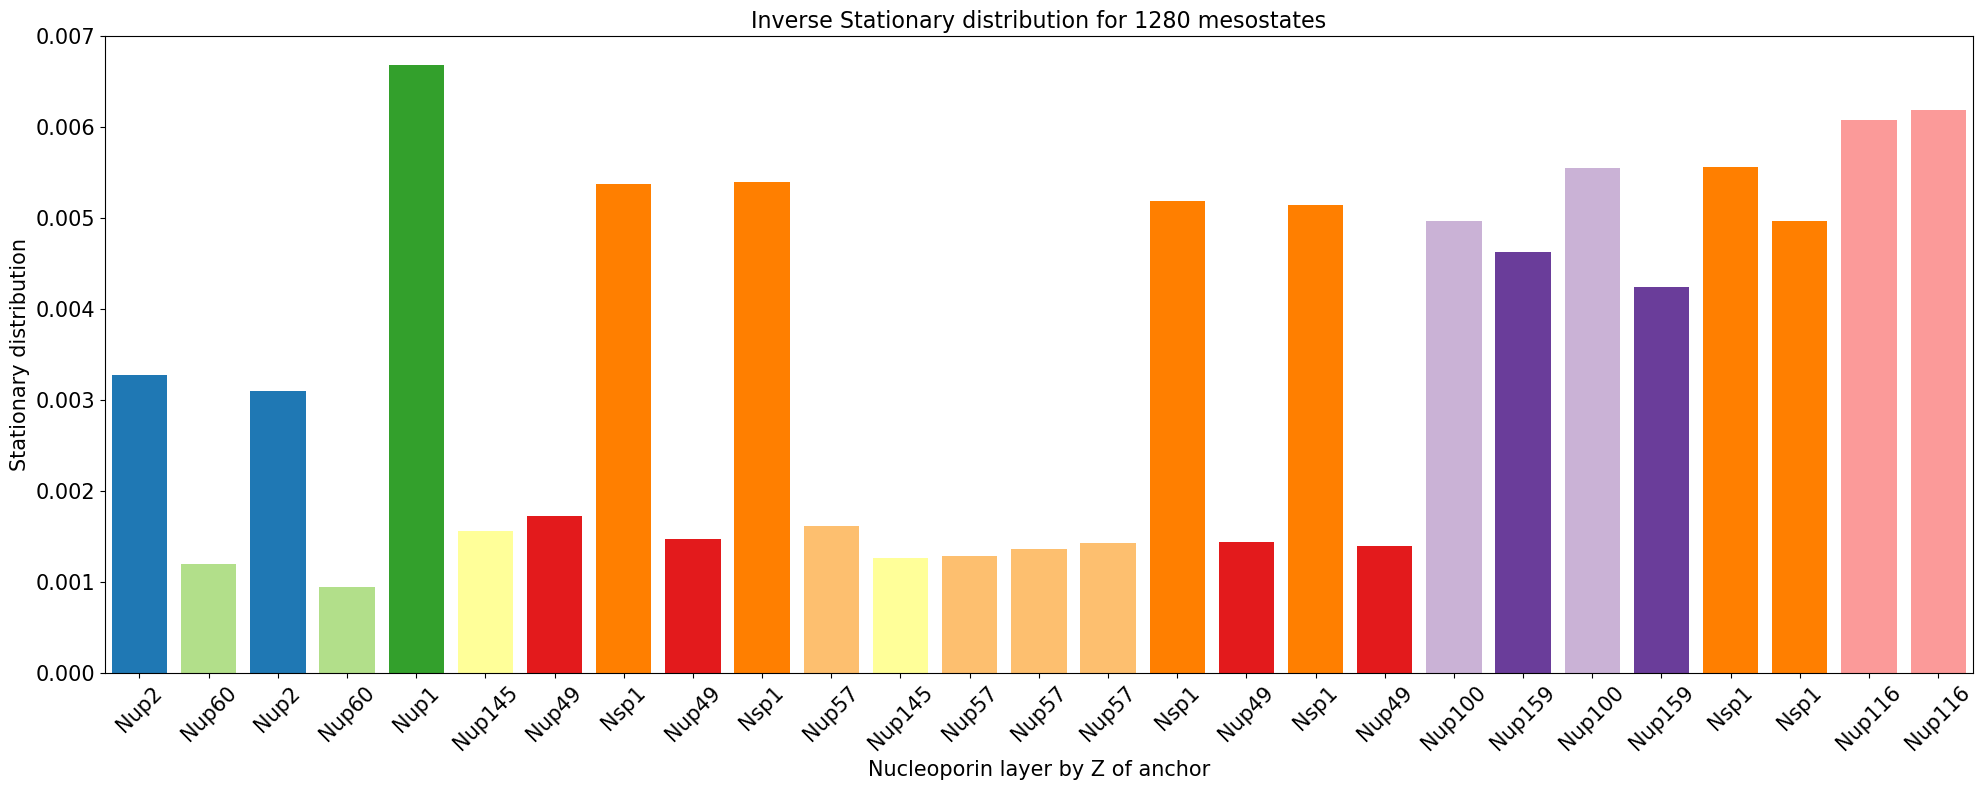

In [6]:
# Validate the stationary distribution

from tkinter import font


def visualize_stationary_distribution(n_clusters):
    with open(f"data/transition_matrices/cluster-kmeans/74pca-{n_clusters}clusters.pickle", "rb") as f:
        P = pickle.load(f)
        
    with open(f"data/clusterings/interactions-150-180-100ns-3k-hist-74pca-kmeans-{n_clusters}clusters.pickle", "rb") as f:
        pca_cluster = pickle.load(f)
        
    pi = stationary_distribution(P)
    pi = pca_cluster.get_inverse_stationary(pi)
    pi = pi[1:-1]

    pi = pi[[i for i in range(len(pi)) if i % 8 == 0]]  # downsample for better visualization
    labels = ["Nup2", "Nup60", "Nup2", "Nup60", "Nup1", "Nup145", "Nup49", "Nsp1", "Nup49", "Nsp1", "Nup57", "Nup145", "Nup57", "Nup57", "Nup57", "Nsp1", "Nup49", "Nsp1", "Nup49", "Nup100", "Nup159", "Nup100", "Nup159", "Nsp1", "Nsp1", "Nup116", "Nup116"]
    colors = ['#a6cee3', '#1f78b4', '#b2df8a', '#33a02c', '#ffff99', 
            '#e31a1c', '#fdbf6f', '#ff7f00', '#cab2d6', '#6a3d9a',
            '#fb9a99', '#b15928']
    colors_labels = ['Nucleus', 'Nup2', 'Nup60', 'Nup1', 'Nup145', 'Nup49', 'Nup57', 'Nsp1', 'Nup100', 'Nup159', 'Nup116', 'Cytoplasm']
    colors_labels_dict = {label: color for label, color in zip(colors_labels, colors)}
    actual_colors = [colors_labels_dict[label] for label in labels]

    plt.figure(figsize=(20, 8))
    plt.bar(range(len(pi)), pi, color=actual_colors)
    plt.xlabel('Nucleoporin layer by Z of anchor', fontsize=15)
    plt.ylabel('Stationary distribution', fontsize=15)
    plt.title(f'Inverse Stationary distribution for {n_clusters} mesostates', fontsize=16)
    plt.xticks(range(len(pi)), labels, fontsize=15, rotation=45)
    plt.yticks(fontsize=15)
    plt.xlim(-0.5, len(pi) - 0.5)
    plt.ylim(0, 0.007)
    plt.tight_layout()
    plt.show()
    
    
for n_clusters in [10, 20, 40, 80, 160, 320, 640, 1280]:
    visualize_stationary_distribution(n_clusters)

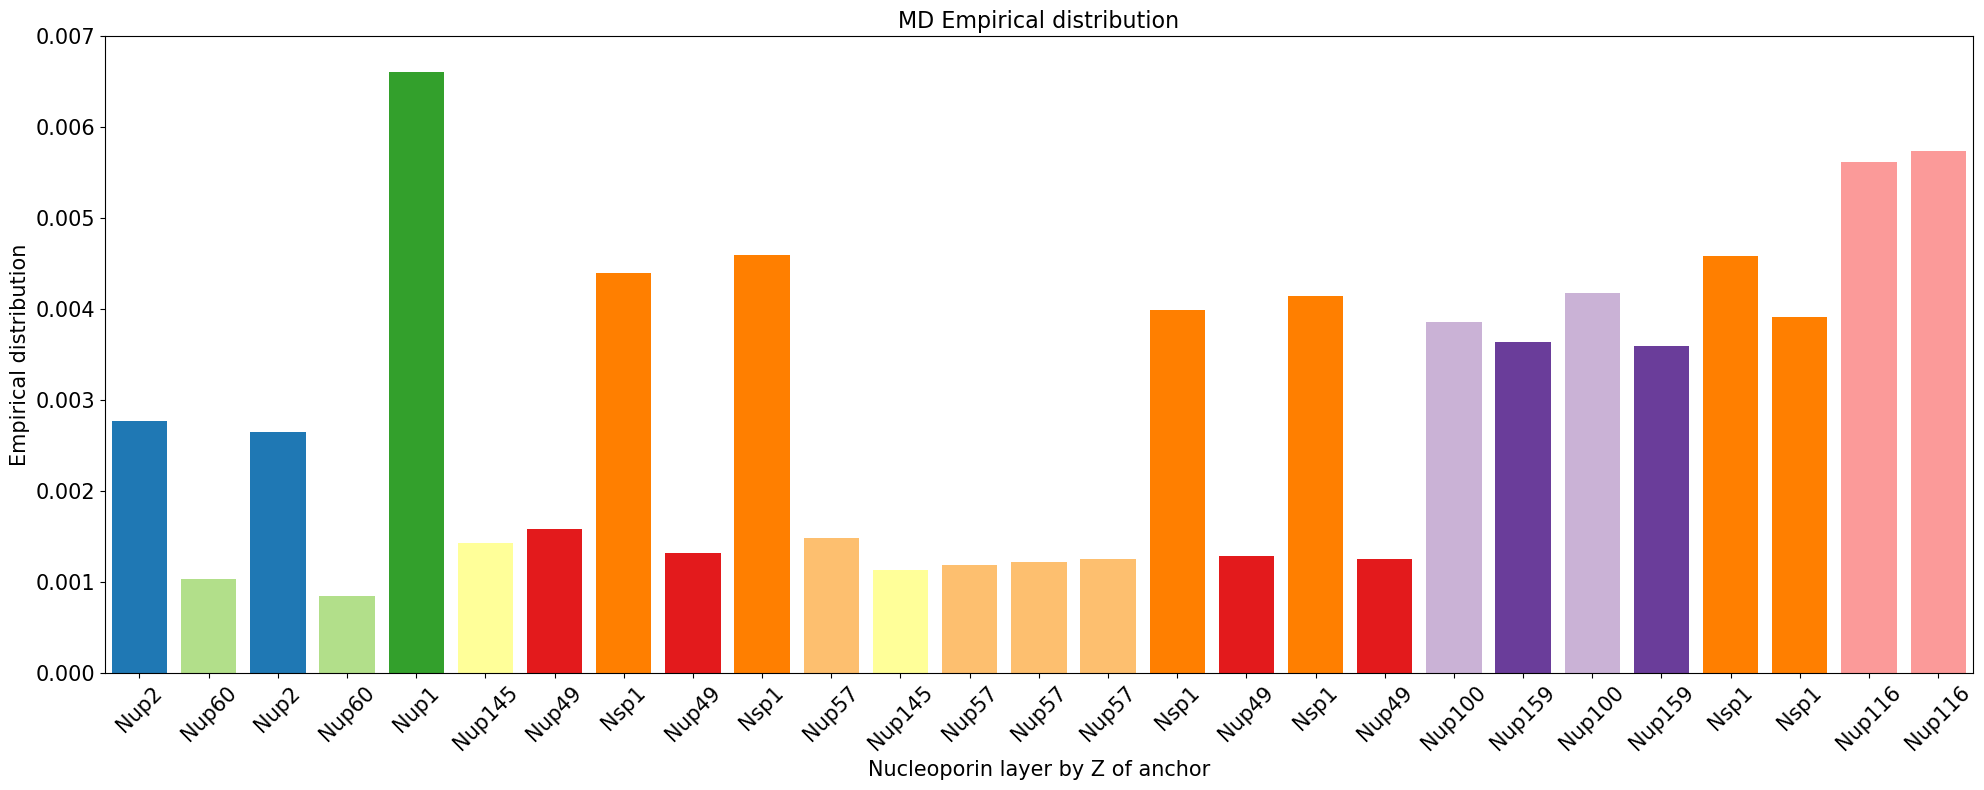

In [7]:
pi = md_empirical = get_md_empiricial_distribution("data/categorized/interactions-150-180-100ns-3k.pickle", 12500, 300)
pi = pi[1:-1]

# 8 sym
pi = pi.reshape(-1, 8)
pi = np.mean(pi, axis=1, keepdims=True)
pi = np.repeat(pi, 8, axis=1).reshape(-1)


pi = pi[[i for i in range(len(pi)) if i % 8 == 0]]  # downsample for better visualization
labels = ["Nup2", "Nup60", "Nup2", "Nup60", "Nup1", "Nup145", "Nup49", "Nsp1", "Nup49", "Nsp1", "Nup57", "Nup145", "Nup57", "Nup57", "Nup57", "Nsp1", "Nup49", "Nsp1", "Nup49", "Nup100", "Nup159", "Nup100", "Nup159", "Nsp1", "Nsp1", "Nup116", "Nup116"]
colors = ['#a6cee3', '#1f78b4', '#b2df8a', '#33a02c', '#ffff99', 
        '#e31a1c', '#fdbf6f', '#ff7f00', '#cab2d6', '#6a3d9a',
        '#fb9a99', '#b15928']
colors_labels = ['Nucleus', 'Nup2', 'Nup60', 'Nup1', 'Nup145', 'Nup49', 'Nup57', 'Nsp1', 'Nup100', 'Nup159', 'Nup116', 'Cytoplasm']
colors_labels_dict = {label: color for label, color in zip(colors_labels, colors)}
actual_colors = [colors_labels_dict[label] for label in labels]

plt.figure(figsize=(20, 8))
plt.bar(range(len(pi)), pi, color=actual_colors)
plt.xlabel('Nucleoporin layer by Z of anchor', fontsize=15)
plt.ylabel('Empirical distribution', fontsize=15)
plt.title(f'MD Empirical distribution', fontsize=16)
plt.xticks(range(len(pi)), labels, fontsize=15, rotation=45)
plt.yticks(fontsize=15)
plt.xlim(-0.5, len(pi) - 0.5)
plt.ylim(0, 0.007)
plt.tight_layout()
plt.show()

/cs/labs/ravehb/roi.eliasian/miniconda3/envs/general_notebooks/lib/python3.10/site-packages/matplotlib/transforms.py:757: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)
/cs/labs/ravehb/roi.eliasian/miniconda3/envs/general_notebooks/lib/python3.10/site-packages/matplotlib/transforms.py:757: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)
/cs/labs/ravehb/roi.eliasian/miniconda3/envs/general_notebooks/lib/python3.10/site-packages/matplotlib/transforms.py:757: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)
/cs/labs/ravehb/roi.eliasian/miniconda3/envs/general_notebooks/lib/python3.10/site-packages/matplotlib/transforms.py:757: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)
/cs/labs/ravehb/roi.eliasian/miniconda3/envs/general_notebooks/l

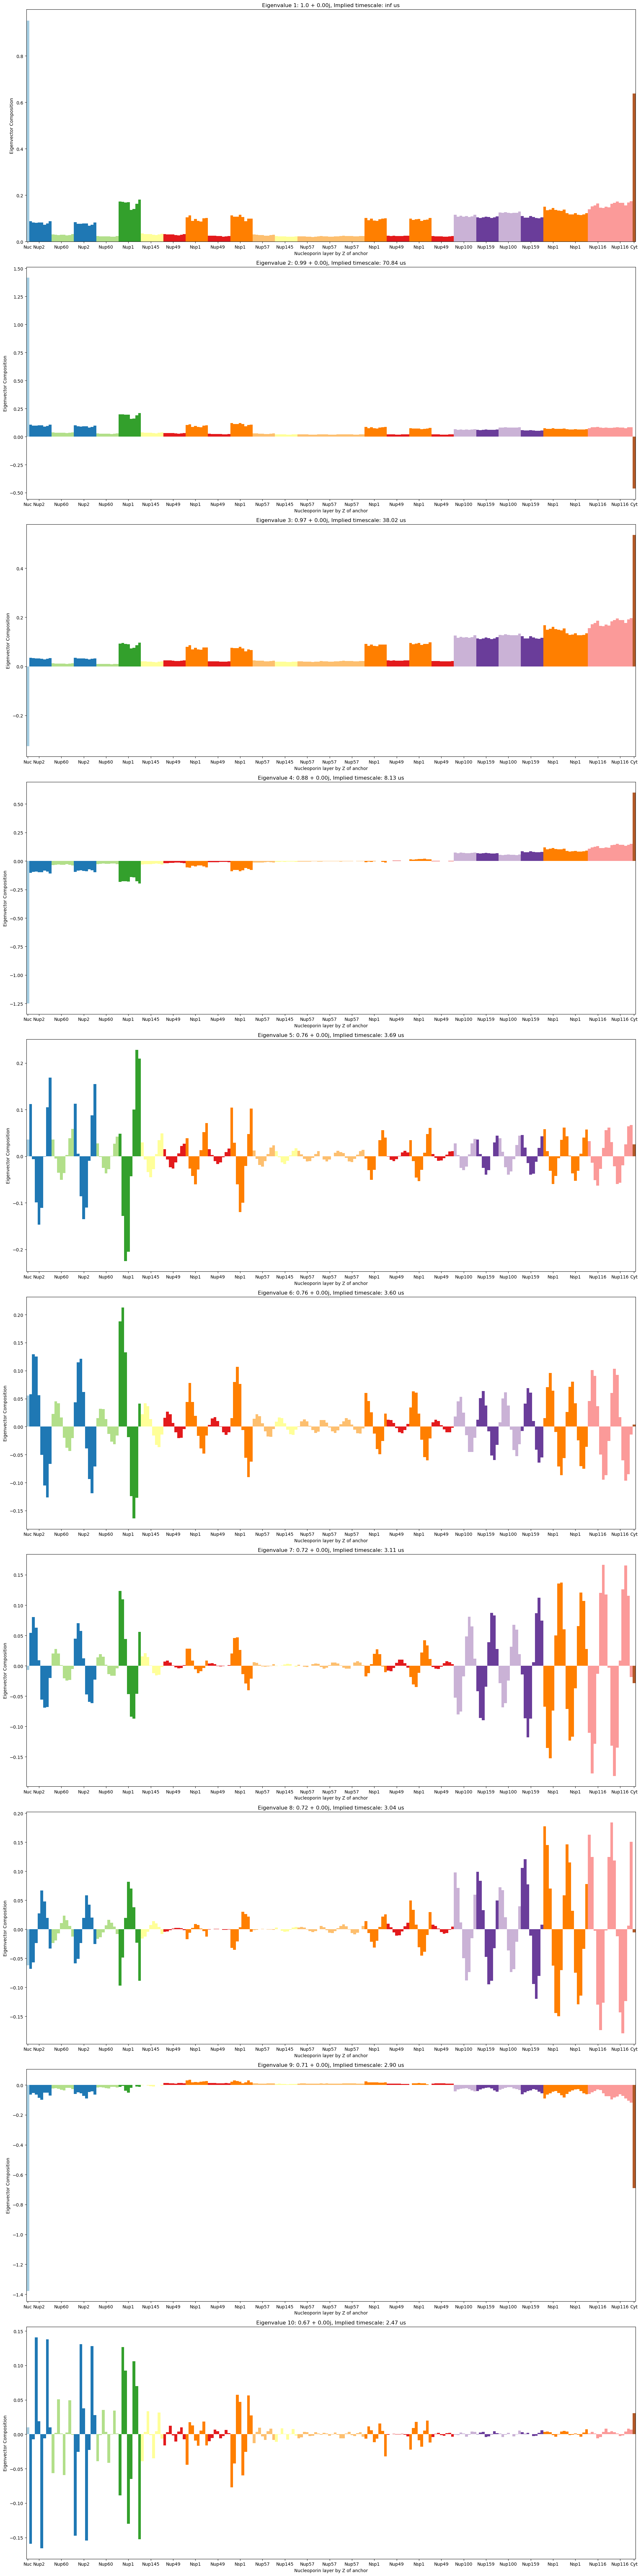

In [54]:
from scipy.linalg import eig

def eigenvalue_to_timescale(eigenvalue, lag_time):
    """
    Convert eigenvalue to implied timescale
    
    Parameters:
    - eigenvalue: eigenvalue from transition matrix
    - lag_time: lag time used to construct transition matrix
    
    Returns:
    - timescale: characteristic time for this process
    """
    if eigenvalue <= 0 or eigenvalue >= 1:
        return np.inf  # Invalid eigenvalue
    
    timescale = -lag_time / np.log(eigenvalue)
    return timescale


def get_right_eigenvalues_eigenvectors(P, n): 
    # Validate input
    if not isinstance(P, np.ndarray):
        P = np.array(P)
    if P.shape[0] != P.shape[1]:
        raise ValueError("Transition matrix must be square")
    if n > P.shape[0]:
        raise ValueError(f"Cannot return {n} eigenvalues from {P.shape[0]}x{P.shape[0]} matrix")
    
    # Compute all eigenvalues and right eigenvectors
    eigenvals, eigenvecs = eig(P, right=True)
    
    # Sort by real part in descending order 
    idx = np.argsort(np.abs(eigenvals))[::-1]
    eigenvals = eigenvals[idx]
    eigenvecs = eigenvecs[:, idx]
    
    # Return the n rightmost eigenvalues and eigenvectors
    return eigenvals[:n], eigenvecs[:, :n].T

with open(f"data/transition_matrices/cluster-kmeans/74pca-{320}clusters.pickle", "rb") as f:
    P = pickle.load(f)
    
with open(f"data/clusterings/interactions-150-180-100ns-3k-hist-74pca-kmeans-{320}clusters.pickle", "rb") as f:
    pca_cluster = pickle.load(f)



n_eigenvecs = 10


eigenvals, eigenvecs = get_right_eigenvalues_eigenvectors(P, n_eigenvecs)

labels = ["Nuc", "Nup2", "Nup60", "Nup2", "Nup60", "Nup1", "Nup145", "Nup49", "Nsp1", "Nup49", "Nsp1", "Nup57", "Nup145", "Nup57", "Nup57", "Nup57", "Nsp1", "Nup49", "Nsp1", "Nup49", "Nup100", "Nup159", "Nup100", "Nup159", "Nsp1", "Nsp1", "Nup116", "Nup116", "Cyt"]
colors = ['#a6cee3', '#1f78b4', '#b2df8a', '#33a02c', '#ffff99', 
        '#e31a1c', '#fdbf6f', '#ff7f00', '#cab2d6', '#6a3d9a',
        '#fb9a99', '#b15928']
colors_labels = ['Nuc', 'Nup2', 'Nup60', 'Nup1', 'Nup145', 'Nup49', 'Nup57', 'Nsp1', 'Nup100', 'Nup159', 'Nup116', 'Cyt']
colors_labels_dict = {label: color for label, color in zip(colors_labels, colors)}

temp_labels = []
for i in range(len(labels)):
    if i == 0 or i == len(labels) - 1:
        temp_labels.append(labels[i])
    else:
        temp_labels += [labels[i]] * 8


actual_colors = [colors_labels_dict[label] for label in temp_labels]

fig, axes = plt.subplots(n_eigenvecs, 1, figsize=(20, 8 * n_eigenvecs))
for i in range(len(eigenvals)):
    timescale = eigenvalue_to_timescale(eigenvals[i].real, 1)  # lag time of 1 us
    eigenvec = eigenvecs[i]
    eigenvec = pca_cluster.get_inverse_stationary(eigenvec)
    # # downsample for better visualization
    # eigenvec = eigenvec[[0] + [j for j in range(1, len(eigenvec) - 1) if j % 8 == 1] + [-1]]
    widths = [1] * len(eigenvec)
    widths[0] = 1
    widths[-1] = 1
    ax = axes[i]
    for j in range(len(eigenvec)):
        ax.bar(j, eigenvec[j], width=widths[j], color=actual_colors[j])
    # plt.bar(range(len(eigenvec)), eigenvec , color=actual_colors)
    ax.set_xlabel('Nucleoporin layer by Z of anchor')
    ax.set_ylabel('Eigenvector Composition')
    ax.set_title(f"Eigenvalue {i+1}: {eigenvals[i].real:.2} + {eigenvals[i].imag:.2f}j, Implied timescale: {timescale:.2f} us")
    ax.set_xticks([0] + [(i * 8) + 4 for i in range(27)] + [217], labels)
    ax.set_xlim(-0.5, len(eigenvec) - 0.5)
    # plt.ylim(0, 0.007)
plt.tight_layout()
plt.show()